In [1]:
import pandas as pd

In [2]:
fruits = pd.read_csv("../Data/fruits.csv")
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


### Feature Data와 Target Data를 Numpy Arrat로 변경

In [4]:
import numpy as np

### 연습

In [ ]:
# numpy 의 column stack과 row stack
testA = np.array([1,2,3,4])
testB = np.array([10,20,30,40])

# 2개의 Array를 묶어서 컬럼 기반의 array로 만들기
[[i,j]for i,j in zip(testA, testB)] # 파이썬 좀 쓰는 사람들은 이렇게 씀 

[[1, 10], [2, 20], [3, 30], [4, 40]]

In [ ]:
# numpy 의 column stack과 row stack
testA = np.array([1,2,3,4])
testB = np.array([10,20,30,40])

# 2개의 Array를 묶어서 컬럼 기반의 array로 만들기 (예전에 쓰던 방식)
combineA = [[i,j]for i,j in zip(testA, testB)]
np.array(combineA)

# numpy에서 컬럼 기반 (최근에 바뀐것)
np.column_stack((testA,testB))

array([[ 1, 10],
       [ 2, 20],
       [ 3, 30],
       [ 4, 40]])

In [16]:
# numpy 의 column stack과 row stack
testA = np.array([1,2,3,4])
testB = np.array([10,20,30,40])

# 2개의 Array를 묶어서 컬럼 기반의 array로 만들기 (예전에 쓰던 방식)
combineA = [[i,j]for i,j in zip(testA, testB)]
print(np.array(combineA))
print("---"*20)

# numpy에서 컬럼 기반 (최근에 바뀐것)
print(np.column_stack((testA,testB)))
print("---"*20)
# numpy 에서 index 기반
print(np.row_stack((testA,testB)))


[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
------------------------------------------------------------
[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
------------------------------------------------------------
[[ 1  2  3  4]
 [10 20 30 40]]


In [17]:
# Fruits의 Feature
fruits_data = np.column_stack((fruits.length, fruits.weight))
fruits_data[:5, :]

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

In [18]:
fruits_data.shape

(49, 2)

In [19]:
# Target
fruits_target = np.array(fruits.name)
fruits_target[:5]

array(['apple', 'apple', 'apple', 'apple', 'apple'], dtype=object)

In [20]:
from sklearn.model_selection import train_test_split

In [ ]:
# Machine Learning을 위한 train과 test 분리
train_input, test_input, train_target, test_target = \
                                            train_test_split(
                                                fruits_data,
                                                fruits_target,
                                                random_state=42, ####
                                                stratify=fruits_target #### 중요하니까 꼭 뺴먹지 말기
                                            )

In [22]:
# kNN을 이용한 혜측
from sklearn.neighbors import KNeighborsClassifier

In [24]:
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

### 수상한 과일

In [ ]:
# length가 25cm 이고 weight가 150g인 과일은?
# 내가 한 정답


kn.fit(train_input,train_target)



KNeighborsClassifier()

In [27]:

kn.score(train_input, train_target)

1.0

In [28]:
import warnings
warnings.filterwarnings('ignore')

In [30]:
kn.predict([[25, 150]])[0]

'berry'

In [32]:
import matplotlib.pyplot as plt

In [ ]:
plt.scatter(
    train_input.length,
    apple.weight
)


plt.scatter(
    berry.length,
    berry.weight
)

plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

In [33]:
# 선생님 정답 
kn.predict([[25, 150]]) # 이거만 바로 하심

array(['berry'], dtype=object)

In [34]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Weight')

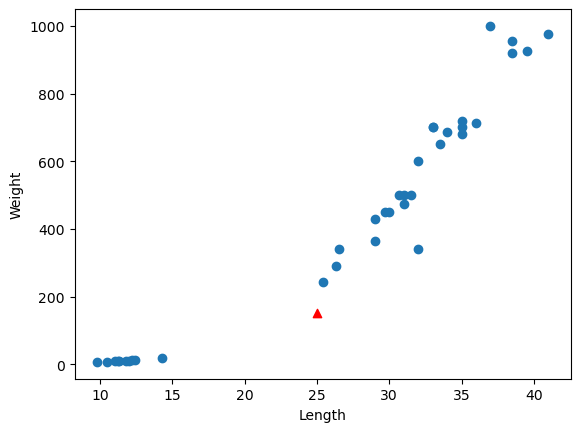

In [ ]:
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)

plt.scatter(
    25,
    150,
    marker="^",
    c="red"
)

plt.xlabel("Length")
plt.ylabel("Weight")
plt.show()

### 

### 이웃을 출력해보자

In [42]:
distance, indexes = kn.kneighbors([[25, 150]])
print(indexes)

[[11 20 13 22 15]]


In [43]:
# 이웃 index에 해당하는 Feature  출력해보기
train_input[indexes]

array([[[ 25.4, 242. ],
        [ 14.3,  19.7],
        [ 12.4,  13.4],
        [ 12.2,  12.2],
        [ 26.3, 290. ]]])

In [44]:
train_target[indexes]

array([['apple', 'berry', 'berry', 'berry', 'apple']], dtype=object)

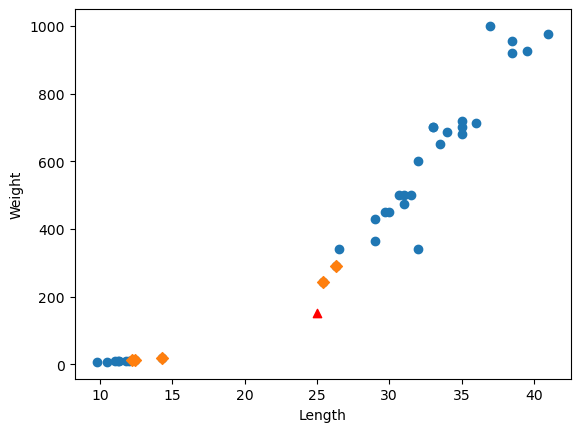

In [45]:
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)

plt.scatter(
    25,
    150,
    marker="^",
    c="red"
)

plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker='D'
)

plt.xlabel("Length")
plt.ylabel("Weight")
plt.show()

---
### 기준을 맞추자

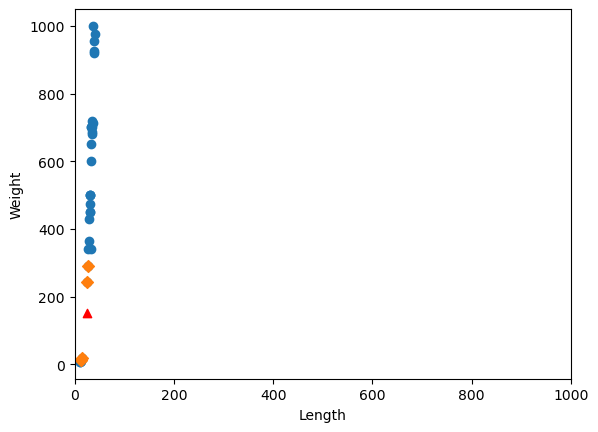

In [46]:
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)

plt.scatter(
    25,
    150,
    marker="^",
    c="red"
)

plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker='D'
)

plt.xlim(0, 1000)
plt.xlabel("Length")
plt.ylabel("Weight")
plt.show()

> smaple이 Lenght에는 거의 영향을 받지 않고 weight에서 영향을 많이 받는다.

### train_data를 표준점수(z점수) 변경 

In [48]:
# length와 weight의 평균
mean = np.mean(train_input, axis=0)
mean

array([ 26.93333333, 441.98333333])

In [49]:
std = np.std(train_input, axis=0)
std

array([ 10.09141549, 325.61300692])

#### 표준점수 = (Feature - 평균) / 표준편차

In [52]:
train_scaled = (train_input - mean) / std
train_scaled[:5,:]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

### sklearn을 이용

In [53]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [55]:
# Method 1
scaler.fit(train_input)

StandardScaler()

In [56]:
train_scaled2 = scaler.transform(train_input)
train_scaled2[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

In [57]:
# Method 2
train_scaled3 = scaler.fit_transform(train_input)
train_scaled3[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

### 전처리 데이터로 모델 훈련하기

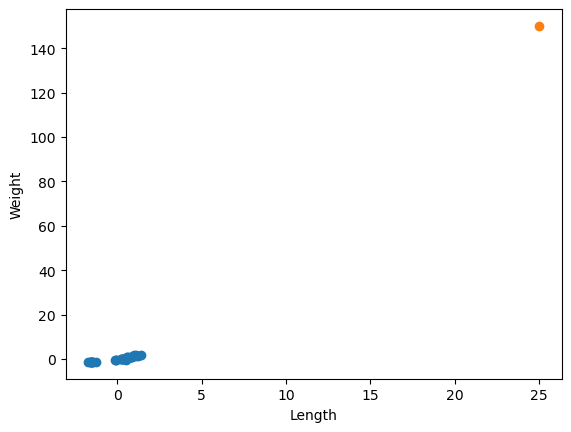

In [58]:
plt.scatter(
    train_scaled3[:,0],
    train_scaled3[:,1]
)

plt.scatter(
    25,
    150
)

plt.xlabel("Length")
plt.ylabel("Weight")

plt.show()

In [59]:
# 예측할 데이터도 표준화 시킨다.
new = ([25,150] - mean) /std
new

array([-0.19158198, -0.89671889])

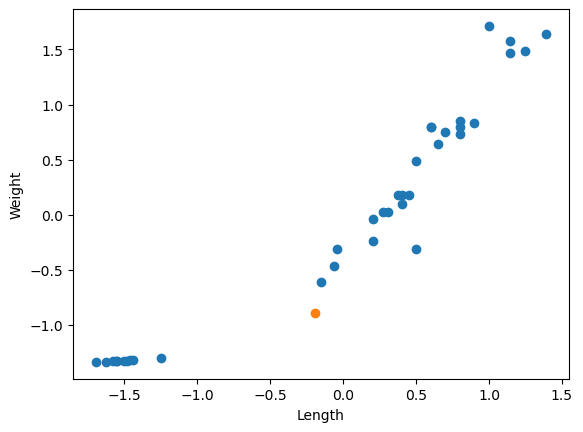

In [60]:
plt.scatter(
    train_scaled3[:,0],
    train_scaled3[:,1]
)

plt.scatter(
    new[0],
    new[1]
)

plt.xlabel("Length")
plt.ylabel("Weight")

plt.show()

# KNN

In [61]:
kn.fit(train_scaled3, train_target)

KNeighborsClassifier()

In [62]:
# -> 오른쪽 같이 하면 절대 안된다 그냥 두개 값이 생기는 거임 train_scaled3 = scaler.fit_transform(train_input) 
test_scaled = (test_input-mean) / std # teain으로 제작된 평균과 표준 편차 사용
kn.score(test_scaled, test_target)

1.0

In [63]:
kn.predict([new])

array(['apple'], dtype=object)

In [69]:
# 이웃 찾기
distance, indexes = kn.kneighbors([new])

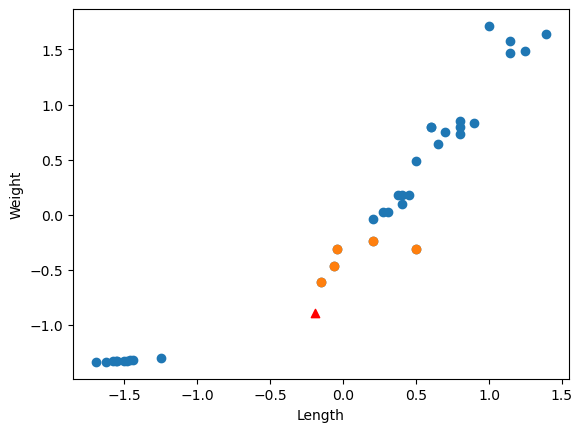

In [70]:
plt.scatter(
    train_scaled3[:,0],
    train_scaled3[:,1]
)

plt.scatter(
    new[0],
    new[1],
    marker="^",
    c="red"
)

plt.scatter(
    train_scaled3[indexes, 0],
    train_scaled3[indexes, 1],
    marker="o"
)

plt.xlabel("Length")
plt.ylabel("Weight")

plt.show()

### iris 불러오기

In [71]:
from sklearn.datasets import load_iris

In [72]:
iris_dataset = load_iris() # Bunch Class

In [73]:
# iris 데이터셋 key 확인
iris_dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [74]:
# Data
iris_dataset['data'][:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

In [75]:
iris_dataset['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [76]:
iris_dataset['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [78]:
print(iris_dataset['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [79]:
iris_dataset['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [80]:
# iris_dataset의 data 크기
iris_dataset['data'].shape

(150, 4)

In [81]:
# iris_dataset의 target 크기
iris_dataset['target'].shape

(150,)

In [84]:
# Train과 Test로 분리
from sklearn.model_selection import train_test_split

In [ ]:
train_input, test_input, train_target, test_target = \
                    train_test_split(
                        iris_dataset['data'],
                        iris_dataset['target'],
                        random_state=42 
                    )
# 내가 한 거 

In [91]:
# 선생님 정답
train_input, test_input, train_target, test_target = \
                    train_test_split(
                        iris_dataset['data'],
                        iris_dataset['target'],
                        random_state=42,
                        stratify=iris_dataset['target']
                    )

In [92]:
print(train_input.shape)
print(train_target.shape)

(112, 4)
(112,)


In [93]:
print(test_input.shape)
print(test_target.shape)

(38, 4)
(38,)


In [94]:
import pandas as pd

In [96]:
# iris_dataframe = # train data 구성하기
iris_dataframe = iris_dataset[['feature_names']]
iris_dataframe.head()

TypeError: unhashable type: 'list'

In [ ]:
# train_input으로 feature_names이게 열이 되는 데이터 프레임 만들기

In [ ]:
# 선생님 정답
pd.DataFrame(train_input) # 1번 

,0,1,2,3
0,7.4,2.8,6.1,1.9
1,7.7,2.8,6.7,2.0
2,5.5,2.4,3.7,1.0
3,6.1,2.8,4.0,1.3
4,5.5,2.5,4.0,1.3
...,...,...,...,...
107,5.0,3.3,1.4,0.2
108,5.1,3.7,1.5,0.4
109,4.8,3.0,1.4,0.3
110,5.8,2.6,4.0,1.2


In [101]:
iris_dataframe =\
    pd.DataFrame(
        train_input,
        columns=iris_dataset['feature_names']
    ) # 3번  
iris_dataframe.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,7.4,2.8,6.1,1.9
1,7.7,2.8,6.7,2.0
2,5.5,2.4,3.7,1.0
3,6.1,2.8,4.0,1.3
4,5.5,2.5,4.0,1.3


In [102]:
import matplotlib.pyplot as plt

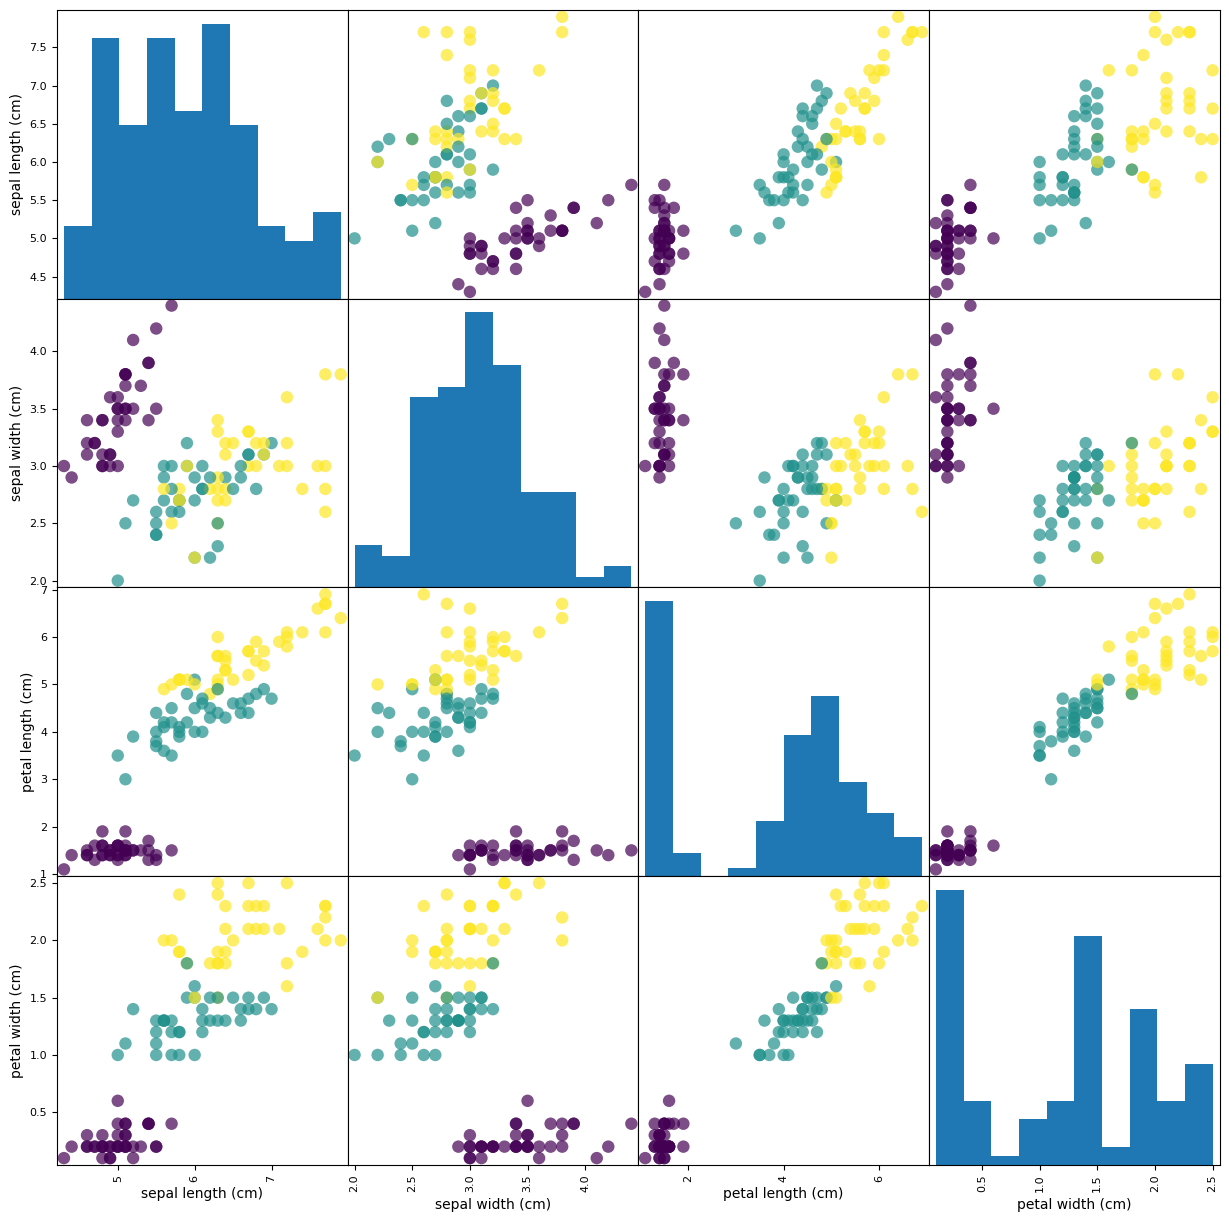

In [ ]:
pd.plotting.scatter_matrix(
    iris_dataframe,
    c=train_target, # 칼라값
    figsize=(15,15),
    marker="o", # ^,*,+,o
    s=80,
    alpha=0.7
)




plt.show()

# KNN으로 예측하기
- 내 주변의 1개만 선택하기   
- test_input으로 예측력 구하기
- SL : 5, SW:2.9, PL:1, PW:0.2일 경우의 품종은?

In [121]:
knn = KNeighborsClassifier(n_neighbors=1)

In [122]:
kn.fit(train_input,train_target)

KNeighborsClassifier()

In [118]:
kn.score(train_input,train_target)

0.9732142857142857

In [123]:
new = [[5, 2.9, 1, 0.2]]

In [ ]:
knn.predict(test_input)

TypeError: 'Bunch' object is not callable

In [ ]:
# 위에가 내가 하던 거

array([0])

In [124]:
# 선생님 정답
knn = KNeighborsClassifier(n_neighbors=1)

In [125]:
knn.fit(train_input, train_target)

KNeighborsClassifier(n_neighbors=1)

In [126]:
knn.score(train_input,train_target)

1.0

In [127]:
knn.score(test_input, test_target)

0.9473684210526315

In [129]:
pred = knn.predict([[5, 2.9, 1, 0.2]])
pred
iris_dataset['target_names'][pred]

array(['setosa'], dtype='<U10')

In [131]:
for i in range(1, 112, 2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(train_input, train_target)
    score = knn.score(test_input, test_target)
    print(f"{i} : {score}")

1 : 0.9473684210526315
3 : 0.9736842105263158
5 : 0.9736842105263158
7 : 0.9473684210526315
9 : 0.9736842105263158
11 : 0.9736842105263158
13 : 0.9473684210526315
15 : 0.9473684210526315
17 : 0.9473684210526315
19 : 0.9473684210526315
21 : 0.9473684210526315
23 : 0.9473684210526315
25 : 0.9473684210526315
27 : 0.9210526315789473
29 : 0.9473684210526315
31 : 0.9473684210526315
33 : 0.9210526315789473
35 : 0.9210526315789473
37 : 0.9210526315789473
39 : 0.9210526315789473
41 : 0.9210526315789473
43 : 0.8947368421052632
45 : 0.8947368421052632
47 : 0.8947368421052632
49 : 0.8947368421052632
51 : 0.8947368421052632
53 : 0.8947368421052632
55 : 0.8947368421052632
57 : 0.8947368421052632
59 : 0.8947368421052632
61 : 0.8947368421052632
63 : 0.868421052631579
65 : 0.8947368421052632
67 : 0.9210526315789473
69 : 0.8947368421052632
71 : 0.8947368421052632
73 : 0.8947368421052632
75 : 0.6578947368421053
77 : 0.6578947368421053
79 : 0.6578947368421053
81 : 0.631578947368421
83 : 0.631578947368421


In [136]:
def knnF(i):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(train_input, train_target)
    train_score = knn.score(train_input, train_target)
    test_score = knn.score(test_input, test_target)
    print(f"{i} : {train_score}, {test_score}, {train_score}-{test_score}")

In [138]:
def knnF(i):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(train_input, train_target)
    train_score = knn.score(train_input, train_target)
    test_score = knn.score(test_input, test_target)
    print(f"{i} : {train_score}, {test_score}, \
        {"과소적합" if(train_score-test_score) <0 else (train_score - test_score)}")

In [139]:
for i in range(1, 11, 2):
    knnF(i)

1 : 1.0, 0.9473684210526315,         0.052631578947368474
3 : 0.9553571428571429, 0.9736842105263158,         과소적합
5 : 0.9732142857142857, 0.9736842105263158,         과소적합
7 : 0.9732142857142857, 0.9473684210526315,         0.025845864661654172
9 : 0.9732142857142857, 0.9736842105263158,         과소적합
